# One-Group, K-Eigenvalue diffusion code

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Method for solving the linear system generated by a 1D finite-difference diffusion equatin
# [ Identical to function given in Canvas ]
def tdma(a, b, c, d):
    """Solve tridiagonal system with lower a, diagonal b, upper c."""
    n = len(b)
    ac, bc, cc, dc = map(np.array, (a, b, c, d), [float]*4)

    for i in range(1, n):
        m = ac[i] / bc[i-1]
        bc[i] -= m * cc[i-1]
        dc[i] -= m * dc[i-1]

    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]

    for i in range(n-2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i+1]) / bc[i]

    return x

# Handles spatial grid discretization, material zoning, and cell mapping.
# [ Identical to function given in Canvas ]
def expand_regions(regions):
    """
    regions: list of dictionaries, one per region.
    Each dictionary has:
        Nc, D, Sigma_a, Q, dx
    """
    D, Sa, Q, dx = [], [], [], []

    for reg in regions:
        Nc = reg["Nc"]
        D.extend([reg["D"]] * Nc)
        Sa.extend([reg["Sigma_a"]] * Nc)
        Q.extend([reg["Q"]] * Nc)
        
        dx.extend([reg["dx"]] * Nc)

    D = np.array(D, dtype=float)
    Sa = np.array(Sa, dtype=float)
    Q = np.array(Q, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D, Sa, Q, dx

# Slightly modified solver from given in Canvas
def solve_slab_diffusion_eigenvalue(regions, fission_source):
    """
    
    """
    # Calls expand_regions to parse out geometry and material tracking arrays
    x, D, Sa, Q, dx = expand_regions(regions)
    N = len(x)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)
    
    rhs = fission_source * dx # Q contains the current iteration's fission source vector

    # Interior interface coupling coefficients
    F = np.zeros(N-1)
    for i in range(N-1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])
        # Equivalent to an interface conductance

    for i in range(N):
        diag[i] += Sa[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N-1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Left reflective BC: no extra leakage term needed and mirror symmetry

    # Right incident partial current BC
    beta = 2.0 * D[-1] / dx[-1]
    alpha = beta / (2.0 * beta + 1.0)

    diag[-1] += alpha
    # I no longer need Jminus_right since it = 0 for a simple vacuum boundary
    # and rhs[-1] does not need adjustment

    phi = tdma(lower, diag, upper, rhs)

    return x, phi

# power iteration loop
# [ New code ]
def run_power_iteration(regions, max_iters=1000, tol=1e-6):

    # Determine total cells from regions
    total_cells = sum(reg["Nc"] for reg in regions)

    # Set an initial flat profile for flux vector
    phi = np.ones(total_cells)

    k = 1.0

    _, _, _, nu_Sigma_f, _ = expand_regions(regions)

    for iteration in range(1, max_iters + 1):
        # compuute updated fission source array
        fission_source = (nu_Sigma_f * phi) / k

        # Call solver
        x_positions, phi_new, = solve_slab_diffusion_eigenvalue(regions, fission_source)
        
        total_production_old = np.sum(nu_Sigma_f * phi)
        total_production_new = np.sum(nu_Sigma_f * phi_new)
        
        k_new = k * (total_production_new / total_production_old)

        k_change = np.max(np.abs(phi_new / np.mean(phi_new) - phi))

        phi = phi_new / np.mean(phi_new)

        if iteration > 1 and k_change < tol:
            break

    else:
        print("Solver timed out before meeting accuracy requirements.")
    return x_positions, phi, k_new

# For problem 5A
def run_bare_critical_search(total_cells, D_jezebel, Sigma_a, nu_Sigma_f_jezebel, thickness_low, thickness_high, tol=1e-5):
    for step in range(1, 35):
        guess_half_thickness = (thickness_low + thickness_high) / 2.0
        dx_cell = guess_half_thickness / total_cells

        regions_config = [{
            "Nc": total_cells,
            "D": D_jezebel,
            "Sigma_a": Sigma_a,
            "Q": nu_Sigma_f_jezebel,
            "dx": dx_cell
        }]

        x, final_flux, keff = run_power_iteration(regions_config)
        print(f"{step:<15}{guess_half_thickness:<30.5f}{keff:<15.5f}")

        if abs(keff - 1.0) < tol:
            print("="*50)
            print(f"Simulated Critical Half-Thickness: {guess_half_thickness:.4f} cm")
            print(f"Total Simulated Critical Slab Width: {2 * guess_half_thickness:.4f} cm")
            break

        if keff < 1.0:
            thickness_low = guess_half_thickness
        else:
            thickness_high = guess_half_thickness

    return x, final_flux, guess_half_thickness

# For problem 5B
def run_reflected_critical_search(core_cells, ref_cells, core_D, core_Sa, core_nuSf, ref_D, ref_Sa, ref_thick, thickness_low, thickness_high, tol=1e-5):
    for step in range(1,35):
        guess_core_half_thickness = (thickness_low + thickness_high) / 2.0
        dx_core = guess_core_half_thickness / core_cells
        dx_ref = ref_thick / ref_cells

        regions_config = [
            { # Zone 1: Core
            "Nc": core_cells,
            "D": core_D,
            "Sigma_a": core_Sa,
            "Q": core_nuSf,
            "dx": dx_core
        }, { # Zone 2: Fixed outside Reactor
            "Nc": ref_cells,
            "D": ref_D,
            "Sigma_a": ref_Sa,
            "Q": 0.0, # Reflector generates no fission neutrons
            "dx": dx_ref
        }]

        x, final_flux, keff = run_power_iteration(regions_config)

        if abs(keff - 1.0) < tol:
            break
        if keff < 1.0:
            thickness_low = guess_core_half_thickness
        else:
            thickness_high = guess_core_half_thickness

    return x, final_flux, guess_core_half_thickness

Question A: How big is a critical slab of Jezebel Pu239? [Solve this problem with 100 equal width spatial cells]. Plot the flux shape as a function of position. How well does it compare with what you might calculate by hand?


JEZEBEL BARE SLAB RESULTS
1              8.00000                       1.35622        
2              4.50000                       1.00304        
3              2.75000                       0.70326        
4              3.62500                       0.86648        
5              4.06250                       0.93787        
6              4.28125                       0.97120        
7              4.39062                       0.98730        
8              4.44531                       0.99522        
9              4.47266                       0.99914        
10             4.48633                       1.00109        
11             4.47949                       1.00012        
12             4.47607                       0.99963        
13             4.47778                       0.99987        
14             4.47864                       1.00000        
Simulated Critical Half-Thickness: 4.4786 cm
Total Simulated Critical Slab Width: 8.9573 cm

Final Simulated Critical H

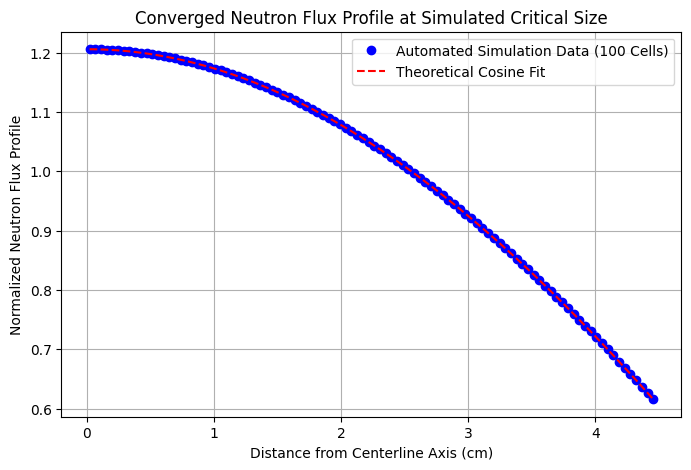

In [9]:
# Given Data for Jezebel from HW5 
Nu = 2.09
Sigma_f = 1.85 # barns
Sigma_gamma = 0.26 # barns
Sigma_tr = 6.8 # barns
density = 15.4 #g/cm^3

# Calculating Values for Solver
# Atom Density N
N_density = (density * 0.60221415) / 239.052163 # atoms/(b-cm)

# Macroscopic constants
Macro_Sigma_f = N_density * Sigma_f # cm^-1
Macro_Sigma_gamma = N_density * Sigma_gamma # cm^-1
Macro_Sigma_tr = N_density * Sigma_tr # cm^-1
Sigma_a = Macro_Sigma_gamma + Macro_Sigma_f # cm^-1

D_jezebel = 1.0 / (3.0 * Macro_Sigma_tr) # cm
nu_Sigma_f_jezebel = Nu * Macro_Sigma_f # cm^-1

# Spatial Grid Config
total_cells = 100

# Run simulation
print("\n" + "="*50)
print("JEZEBEL BARE SLAB RESULTS")
print("="*50)

x, final_flux, critical_half_thickness = run_bare_critical_search(total_cells, D_jezebel, Sigma_a, nu_Sigma_f_jezebel, 1.0, 15.0)

print(f"\nFinal Simulated Critical Half-Thickness: {critical_half_thickness:.4f} cm")
print(f"\nTotal Critical Slab Thickness: {2 * critical_half_thickness:.4f} cm")
print("="*50 + "\n")

plt.figure(figsize=(8, 5))
plt.plot(x, final_flux, 'bo', label='Automated Simulation Data (100 Cells)')

# Verify the simulation profile shape against an analytical benchmark model
B2 = (nu_Sigma_f_jezebel - Sigma_a) / D_jezebel
B = np.sqrt(B2)
analytical_flux = final_flux[0] * np.cos(B * x)

plt.plot(x, analytical_flux, 'r--', label='Theoretical Cosine Fit')
plt.title('Converged Neutron Flux Profile at Simulated Critical Size')
plt.xlabel('Distance from Centerline Axis (cm)')
plt.ylabel('Normalized Neutron Flux Profile')
plt.grid(True)
plt.legend()
plt.show()

Question B: Model a reflected slab reactor with the following properties:

Core: D= $1.587 \mathrm{~cm}, \Sigma_a=0.14 \mathrm{~cm}^{-1}, \nu \Sigma_f=0.17 \mathrm{~cm}^{-1}$
Reflector: D $=3.3333 \mathrm{~cm}, \Sigma_a=0.02 \mathrm{~cm}^{-1}, \nu \Sigma_f=0 \mathrm{~cm}^{-1}$
If the reflector is 10 cm thick, how big is a critical slab of this material? Use 50 cells in the moderator, and 200 cells in the core.


REFLECTED SLAB RESULTS
Critical Core Half-Thickness : 6.8013 cm
Total Critical Core Width    : 13.6025 cm
Total Reactor Width (2x(C+R)): 33.6025 cm



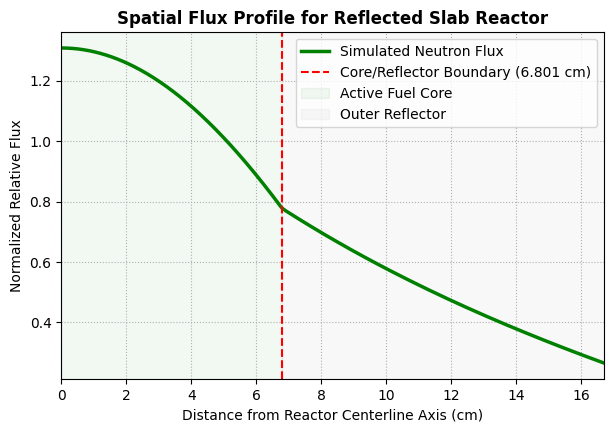

In [7]:
core_cells = 200
ref_cells = 50

core_D = 1.587
core_Sa = 0.14
core_nuSf = 0.17

ref_D = 3.333
ref_Sa = 0.02
ref_thick = 10.0

x_ref, flux_ref, critical_core_half_size = run_reflected_critical_search(
    core_cells = core_cells,
    ref_cells = ref_cells,
    core_D = core_D,
    core_Sa = core_Sa,
    core_nuSf = core_nuSf,
    ref_D = ref_D,
    ref_Sa = ref_Sa,
    ref_thick = ref_thick,
    thickness_low = 1.0,
    thickness_high = 50.0
)

print("\n" + "="*50)
print("REFLECTED SLAB RESULTS")
print("="*50)
print(f"Critical Core Half-Thickness : {critical_core_half_size:.4f} cm")
print(f"Total Critical Core Width    : {2 * critical_core_half_size:.4f} cm")
print(f"Total Reactor Width (2x(C+R)): {2 * (critical_core_half_size + ref_thick):.4f} cm")
print("="*50 + "\n")

# Plot results
plt.figure(figsize=(7, 4.5))

plt.plot(x_ref, flux_ref, 'g-', linewidth=2.5, label='Simulated Neutron Flux')

plt.axvline(x=critical_core_half_size, color='red', linestyle='--', linewidth=1.5, 
            label=f'Core/Reflector Boundary ({critical_core_half_size:.3f} cm)')
plt.axvspan(0, critical_core_half_size, alpha=0.05, color='green', label='Active Fuel Core')
plt.axvspan(critical_core_half_size, x_ref[-1], alpha=0.05, color='gray', label='Outer Reflector')
plt.title('Spatial Flux Profile for Reflected Slab Reactor', fontsize=12, fontweight='bold')
plt.xlabel('Distance from Reactor Centerline Axis (cm)')
plt.ylabel('Normalized Relative Flux')
plt.xlim(0, x_ref[-1])
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')
plt.show()